In [50]:
"""
HEALTHCARE READMISSION ANALYSIS PROJECT
======================================
Author: Navya
Date: May 2026

This project focuses on analyzing hospital readmissions among diabetes patients.
The analysis includes:
1. Data acquisition and loading
2. Data cleaning and preprocessing
3. Exploratory Data Analysis (EDA)
4. Data visualization
5. Healthcare insights and recommendations

Target Audience: Analytics students and healthcare data enthusiasts
"""

# ============================================================================
# SECTION 1: ENVIRONMENT SETUP AND LIBRARY IMPORTS
# ============================================================================

# Data manipulation and analysis
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Utility libraries
import warnings
import os
from datetime import datetime

# Configuration settings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8-darkgrid')

print("=" * 80)
print("HEALTHCARE READMISSION ANALYSIS PROJECT")
print("=" * 80)
print(f"Execution started at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("All libraries imported successfully!\n")

HEALTHCARE READMISSION ANALYSIS PROJECT
Execution started at: 2026-06-05 21:28:37
All libraries imported successfully!



In [51]:
# ============================================================================
# SECTION 2: DATA ACQUISITION
# ============================================================================

"""
Dataset: Diabetes 130-US Hospitals Dataset

Dataset characteristics:
- 101,766 hospital admissions
- ~50 features (patient demographics, diagnoses, medications, procedures)
- Key variable of interest: Readmission status
"""

print("\n" + "=" * 80)
print("DATA ACQUISITION")
print("=" * 80)

# Dataset file
data_file = "diabetic_data.csv"

# Check if dataset exists
if os.path.exists(data_file):
    print(f"✓ Data file '{data_file}' found.")
else:
    print(f"✗ Data file '{data_file}' not found.")
    print("Please place the dataset in the working directory.")

# Load dataset
try:
    print("\nLoading dataset...")

    df_raw = pd.read_csv(data_file)

    print("✓ Dataset loaded successfully!")
    print(f"Shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
    print(
        f"Memory usage: "
        f"{df_raw.memory_usage(deep=True).sum() / 1024**2:.2f} MB"
    )

except FileNotFoundError:
    print("\nDataset not found.")
    raise

print("\n" + "-" * 80)
print("INITIAL DATA PREVIEW")
print("-" * 80)

print("\nFirst 5 Rows:")
print(df_raw.head())

print("\nDataset Information:")
df_raw.info()

print("\nBasic Statistical Summary:")
print(df_raw.describe())


DATA ACQUISITION
✓ Data file 'diabetic_data.csv' found.

Loading dataset...
✓ Dataset loaded successfully!
Shape: 101,766 rows × 50 columns
Memory usage: 225.23 MB

--------------------------------------------------------------------------------
INITIAL DATA PREVIEW
--------------------------------------------------------------------------------

First 5 Rows:
   encounter_id  patient_nbr             race  gender      age weight  \
0       2278392      8222157        Caucasian  Female   [0-10)      ?   
1        149190     55629189        Caucasian  Female  [10-20)      ?   
2         64410     86047875  AfricanAmerican  Female  [20-30)      ?   
3        500364     82442376        Caucasian    Male  [30-40)      ?   
4         16680     42519267        Caucasian    Male  [40-50)      ?   

   admission_type_id  discharge_disposition_id  admission_source_id  \
0                  6                        25                    1   
1                  1                         1         



DATA QUALITY ASSESSMENT

1. DUPLICATE RECORDS CHECK
--------------------------------------------------------------------------------
Total duplicate rows: 0


2. MISSING VALUES ANALYSIS
--------------------------------------------------------------------------------
✓ No missing values detected in the dataset!


3. PLACEHOLDER VALUES CHECK
--------------------------------------------------------------------------------
Healthcare datasets often use '?' or 'Unknown' as placeholders.

Columns with '?' placeholders: 7
  - weight: 98,569 (96.86%)
  - medical_specialty: 49,949 (49.08%)
  - payer_code: 40,256 (39.56%)
  - race: 2,273 (2.23%)
  - diag_3: 1,423 (1.4%)
  - diag_2: 358 (0.35%)
  - diag_1: 21 (0.02%)


4. DATA TYPES SUMMARY
--------------------------------------------------------------------------------
object    37
int64     13
dtype: int64


Columns by data type:

int64:
  Count: 13
  Columns: encounter_id, patient_nbr, admission_type_id, discharge_disposition_id, admission_s

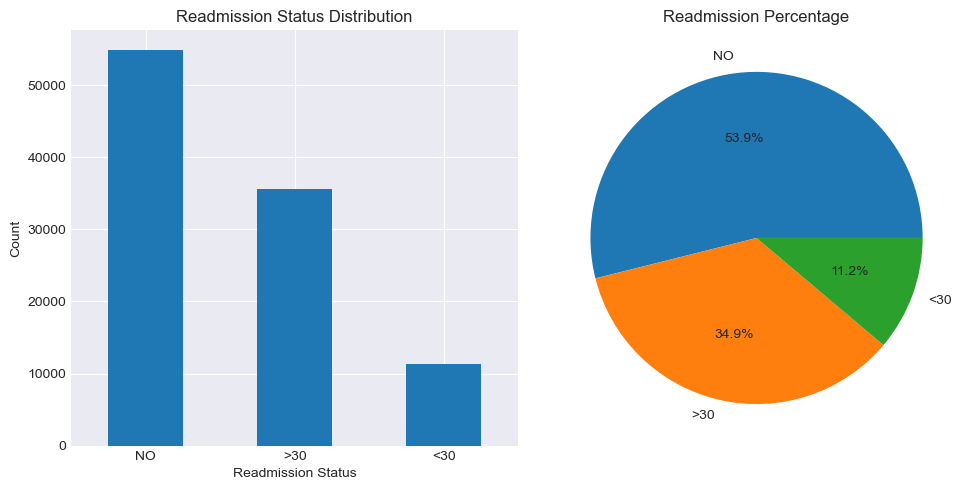

In [33]:
# ============================================================================
# SECTION 3: DATA QUALITY ASSESSMENT
# ============================================================================

"""
Before any analysis, we must understand data quality issues:
1. Missing values
2. Duplicate records
3. Data types
4. Value distributions
5. Outliers

This step is CRITICAL - poor data quality leads to poor insights!
"""

print("\n\n" + "=" * 80)
print("DATA QUALITY ASSESSMENT")
print("=" * 80)

# Create a copy for preprocessing (preserve raw data)
df = df_raw.copy()

# 3.1 Check for duplicate records
print("\n1. DUPLICATE RECORDS CHECK")
print("-" * 80)
duplicates = df.duplicated().sum()
print(f"Total duplicate rows: {duplicates:,}")

if duplicates > 0:
    print(f"Percentage of duplicates: {duplicates/len(df)*100:.2f}%")
    # Note: We'll keep duplicates as they represent separate encounters
    print("Note: In healthcare, duplicate rows may represent separate patient encounters.")
    print("We'll retain them for now and investigate further.")

# 3.2 Missing values analysis
print("\n\n2. MISSING VALUES ANALYSIS")
print("-" * 80)

# Calculate missing values
missing_data = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df) * 100).round(2)
})
missing_data = missing_data[missing_data['Missing_Count'] > 0].sort_values(
    'Missing_Percentage', ascending=False
)

if len(missing_data) > 0:
    print(f"\nColumns with missing values: {len(missing_data)}")
    print("\n" + missing_data.to_string(index=False))
else:
    print("✓ No missing values detected in the dataset!")

# 3.3 Check for placeholder values (common in healthcare data)
print("\n\n3. PLACEHOLDER VALUES CHECK")
print("-" * 80)
print("Healthcare datasets often use '?' or 'Unknown' as placeholders.")

# Count '?' occurrences in each column
placeholder_counts = {}
for col in df.columns:
    if df[col].dtype == 'object':  # Only check string columns
        placeholder_count = (df[col] == '?').sum()
        if placeholder_count > 0:
            placeholder_counts[col] = {
                'count': placeholder_count,
                'percentage': round(placeholder_count / len(df) * 100, 2)
            }

if placeholder_counts:
    print(f"\nColumns with '?' placeholders: {len(placeholder_counts)}")
    for col, stats in sorted(placeholder_counts.items(),
                            key=lambda x: x[1]['percentage'],
                            reverse=True):
        print(f"  - {col}: {stats['count']:,} ({stats['percentage']}%)")
else:
    print("✓ No '?' placeholders found!")

# 3.4 Data types examination
print("\n\n4. DATA TYPES SUMMARY")
print("-" * 80)
dtype_summary = df.dtypes.value_counts()
print(dtype_summary)

print("\n\nColumns by data type:")
for dtype in df.dtypes.unique():
    cols = df.select_dtypes(include=[dtype]).columns.tolist()
    print(f"\n{dtype}:")
    print(f"  Count: {len(cols)}")
    print(f"  Columns: {', '.join(cols[:5])}{'...' if len(cols) > 5 else ''}")

# 3.5 Readmission Status Analysis
print("\n\n5. READMISSION STATUS ANALYSIS")
print("-" * 80)
print("Analyzing patient readmission patterns.")

if 'readmitted' in df.columns:
    print("\nReadmission status distribution:")
    readmit_dist = df['readmitted'].value_counts()
    print(readmit_dist)

    print("\nPercentages:")
    print((readmit_dist / len(df) * 100).round(2))

    # Visualization
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    readmit_dist.plot(kind='bar')
    plt.title('Readmission Status Distribution')
    plt.xlabel('Readmission Status')
    plt.ylabel('Count')
    plt.xticks(rotation=0)

    plt.subplot(1, 2, 2)
    plt.pie(
        readmit_dist.values,
        labels=readmit_dist.index,
        autopct='%1.1f%%'
    )
    plt.title('Readmission Percentage')

    plt.tight_layout()
    plt.savefig('01_readmission_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()

In [34]:
# ============================================================================
# SECTION 4: DATA CLEANING AND PREPROCESSING
# ============================================================================

"""
This section focuses on preparing the dataset for analysis.

Tasks performed:
1. Handle placeholder values
2. Remove unnecessary columns
3. Handle missing values
4. Create meaningful diagnosis categories
5. Convert age ranges into numeric values
"""

print("\n\n" + "=" * 80)
print("DATA CLEANING AND PREPROCESSING")
print("=" * 80)

# 4.1 Replace Placeholder Values
print("\n1. REPLACING PLACEHOLDER VALUES")
print("-" * 80)

df = df.replace('?', np.nan)

print("✓ Replaced '?' values with NaN")

# 4.2 Remove Unnecessary Columns
print("\n2. REMOVING UNNECESSARY COLUMNS")
print("-" * 80)

columns_to_drop = [
    'encounter_id',
    'patient_nbr',
    'weight',
    'payer_code',
    'medical_specialty'
]

for col in columns_to_drop:
    if col in df.columns:
        df.drop(columns=col, inplace=True)

print(f"✓ Dataset shape after column removal: {df.shape}")

# 4.3 Handle Missing Values
print("\n3. HANDLING MISSING VALUES")
print("-" * 80)

categorical_fill_cols = [
    'race',
    'gender',
    'diag_1',
    'diag_2',
    'diag_3'
]

for col in categorical_fill_cols:
    if col in df.columns:
        missing_before = df[col].isnull().sum()
        df[col] = df[col].fillna('Unknown')

        print(
            f"{col}: "
            f"{missing_before:,} missing values filled"
        )

print("\n✓ Missing value treatment completed")

# 4.4 Diagnosis Category Engineering
print("\n4. DIAGNOSIS CATEGORY CREATION")
print("-" * 80)

def categorize_diagnosis(diag_code):

    if pd.isna(diag_code) or diag_code == 'Unknown':
        return 'Unknown'

    diag_str = str(diag_code)

    try:

        if diag_str.startswith('V') or diag_str.startswith('E'):
            return 'Other'

        code = float(diag_str)

        if 390 <= code <= 459 or code == 785:
            return 'Circulatory'

        elif 460 <= code <= 519 or code == 786:
            return 'Respiratory'

        elif 520 <= code <= 579 or code == 787:
            return 'Digestive'

        elif 250 <= code < 251:
            return 'Diabetes'

        elif 800 <= code <= 999:
            return 'Injury'

        elif 710 <= code <= 739:
            return 'Musculoskeletal'

        elif 580 <= code <= 629 or code == 788:
            return 'Genitourinary'

        elif 140 <= code <= 239:
            return 'Neoplasms'

        else:
            return 'Other'

    except:
        return 'Other'


for diag_col in ['diag_1', 'diag_2', 'diag_3']:

    if diag_col in df.columns:

        new_col = f'{diag_col}_category'

        df[new_col] = df[diag_col].apply(
            categorize_diagnosis
        )

        print(f"✓ Created {new_col}")

print("\n✓ Diagnosis categories created successfully")

# 4.5 Convert Age Ranges to Numeric
print("\n5. CONVERTING AGE TO NUMERIC")
print("-" * 80)

age_mapping = {
    '[0-10)': 5,
    '[10-20)': 15,
    '[20-30)': 25,
    '[30-40)': 35,
    '[40-50)': 45,
    '[50-60)': 55,
    '[60-70)': 65,
    '[70-80)': 75,
    '[80-90)': 85,
    '[90-100)': 95
}

if 'age' in df.columns:

    df['age_numeric'] = df['age'].map(age_mapping)

    print("✓ Numeric age column created")

    print(
        f"Age Range: "
        f"{df['age_numeric'].min()} - "
        f"{df['age_numeric'].max()}"
    )

print("\n" + "=" * 80)
print("DATA CLEANING COMPLETE")
print("=" * 80)

print(
    f"Final Dataset Shape: "
    f"{df.shape[0]:,} rows × {df.shape[1]} columns"
)

print("Dataset is ready for exploratory data analysis.")

output_file = "diabetic_data_cleaned.csv"

df.to_csv(output_file, index=False)

print(f"\n✓ Cleaned dataset saved as '{output_file}'")



DATA CLEANING AND PREPROCESSING

1. REPLACING PLACEHOLDER VALUES
--------------------------------------------------------------------------------
✓ Replaced '?' values with NaN

2. REMOVING UNNECESSARY COLUMNS
--------------------------------------------------------------------------------
✓ Dataset shape after column removal: (101766, 45)

3. HANDLING MISSING VALUES
--------------------------------------------------------------------------------
race: 2,273 missing values filled
gender: 0 missing values filled
diag_1: 21 missing values filled
diag_2: 358 missing values filled
diag_3: 1,423 missing values filled

✓ Missing value treatment completed

4. DIAGNOSIS CATEGORY CREATION
--------------------------------------------------------------------------------
✓ Created diag_1_category
✓ Created diag_2_category
✓ Created diag_3_category

✓ Diagnosis categories created successfully

5. CONVERTING AGE TO NUMERIC
---------------------------------------------------------------------------

In [35]:
# ============================================================================
# SECTION 5: CLEANED DATA SUMMARY
# ============================================================================

print("\n\n" + "=" * 80)
print("CLEANED DATASET SUMMARY")
print("=" * 80)

# 5.1 Numeric features summary
print("\n1. NUMERIC FEATURES SUMMARY")
print("-" * 80)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Number of numeric features: {len(numeric_cols)}")
print("\nKey numeric features:")
key_numeric = ['time_in_hospital', 'num_lab_procedures', 'num_procedures',
               'num_medications', 'number_outpatient', 'number_emergency',
               'number_inpatient', 'number_diagnoses', 'age_numeric']

for col in key_numeric:
    if col in df.columns:
        print(f"\n{col}:")
        print(f"  Mean: {df[col].mean():.2f}")
        print(f"  Median: {df[col].median():.2f}")
        print(f"  Std Dev: {df[col].std():.2f}")
        print(f"  Range: [{df[col].min()}, {df[col].max()}]")

# 5.2 Categorical features summary
print("\n\n2. CATEGORICAL FEATURES SUMMARY")
print("-" * 80)
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"Number of categorical features: {len(categorical_cols)}")

print("\nKey categorical features and their unique values:")
key_categorical = ['race', 'gender', 'admission_type_id', 'discharge_disposition_id',
                   'admission_source_id', 'diag_1_category', 'diabetesMed', 'change']

for col in key_categorical:
    if col in df.columns:
        unique_count = df[col].nunique()
        print(f"\n{col}: {unique_count} unique values")
        if unique_count <= 10:  # Show distribution for low-cardinality features
            print(df[col].value_counts().head())

# 5.3 Data quality final check
print("\n\n3. FINAL DATA QUALITY CHECK")
print("-" * 80)
print(f"Total records: {len(df):,}")
print(f"Total features: {df.shape[1]}")
print(f"\nMissing values remaining:")
remaining_missing = df.isnull().sum().sum()
print(f"  Total: {remaining_missing:,}")

if remaining_missing > 0:
    print(f"  Percentage: {remaining_missing / (df.shape[0] * df.shape[1]) * 100:.4f}%")
else:
    print("  ✓ No missing values!")

print("\n✓ Dataset is clean and ready for analysis!")



CLEANED DATASET SUMMARY

1. NUMERIC FEATURES SUMMARY
--------------------------------------------------------------------------------
Number of numeric features: 12

Key numeric features:

time_in_hospital:
  Mean: 4.40
  Median: 4.00
  Std Dev: 2.99
  Range: [1, 14]

num_lab_procedures:
  Mean: 43.10
  Median: 44.00
  Std Dev: 19.67
  Range: [1, 132]

num_procedures:
  Mean: 1.34
  Median: 1.00
  Std Dev: 1.71
  Range: [0, 6]

num_medications:
  Mean: 16.02
  Median: 15.00
  Std Dev: 8.13
  Range: [1, 81]

number_outpatient:
  Mean: 0.37
  Median: 0.00
  Std Dev: 1.27
  Range: [0, 42]

number_emergency:
  Mean: 0.20
  Median: 0.00
  Std Dev: 0.93
  Range: [0, 76]

number_inpatient:
  Mean: 0.64
  Median: 0.00
  Std Dev: 1.26
  Range: [0, 21]

number_diagnoses:
  Mean: 7.42
  Median: 8.00
  Std Dev: 1.93
  Range: [1, 16]

age_numeric:
  Mean: 65.97
  Median: 65.00
  Std Dev: 15.94
  Range: [5, 95]


2. CATEGORICAL FEATURES SUMMARY
-----------------------------------------------------



EXPLORATORY DATA ANALYSIS

1. UNIVARIATE ANALYSIS - NUMERIC FEATURES
--------------------------------------------------------------------------------
✓ Saved: visualizations/02_numeric_distributions.png


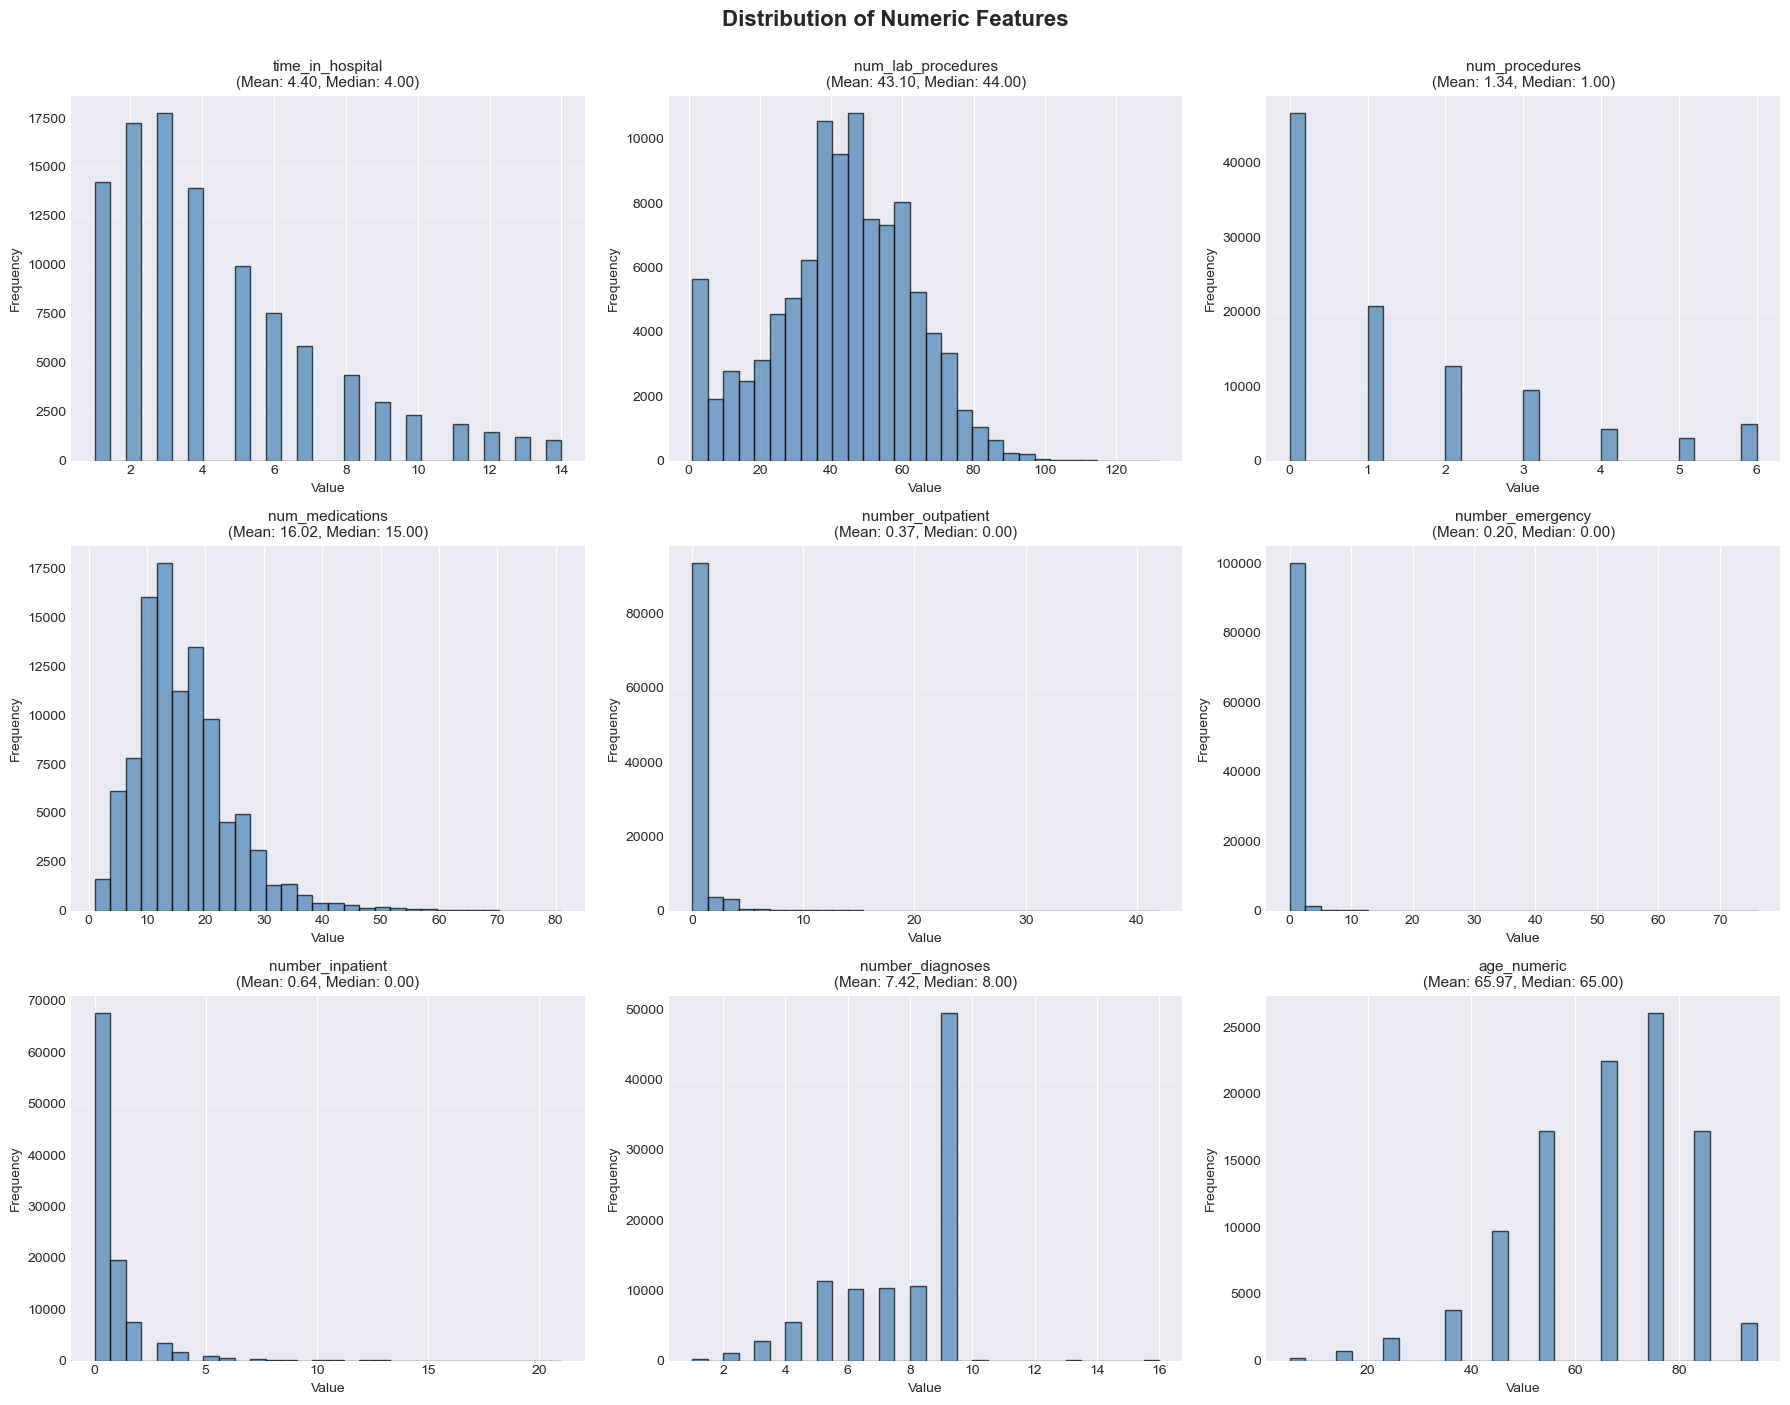


Statistical Summary of Numeric Features:
       time_in_hospital  num_lab_procedures  num_procedures  num_medications  \
count         101766.00           101766.00       101766.00        101766.00   
mean               4.40               43.10            1.34            16.02   
std                2.99               19.67            1.71             8.13   
min                1.00                1.00            0.00             1.00   
25%                2.00               31.00            0.00            10.00   
50%                4.00               44.00            1.00            15.00   
75%                6.00               57.00            2.00            20.00   
max               14.00              132.00            6.00            81.00   

       number_outpatient  number_emergency  number_inpatient  \
count          101766.00         101766.00         101766.00   
mean                0.37              0.20              0.64   
std                 1.27              0.93   

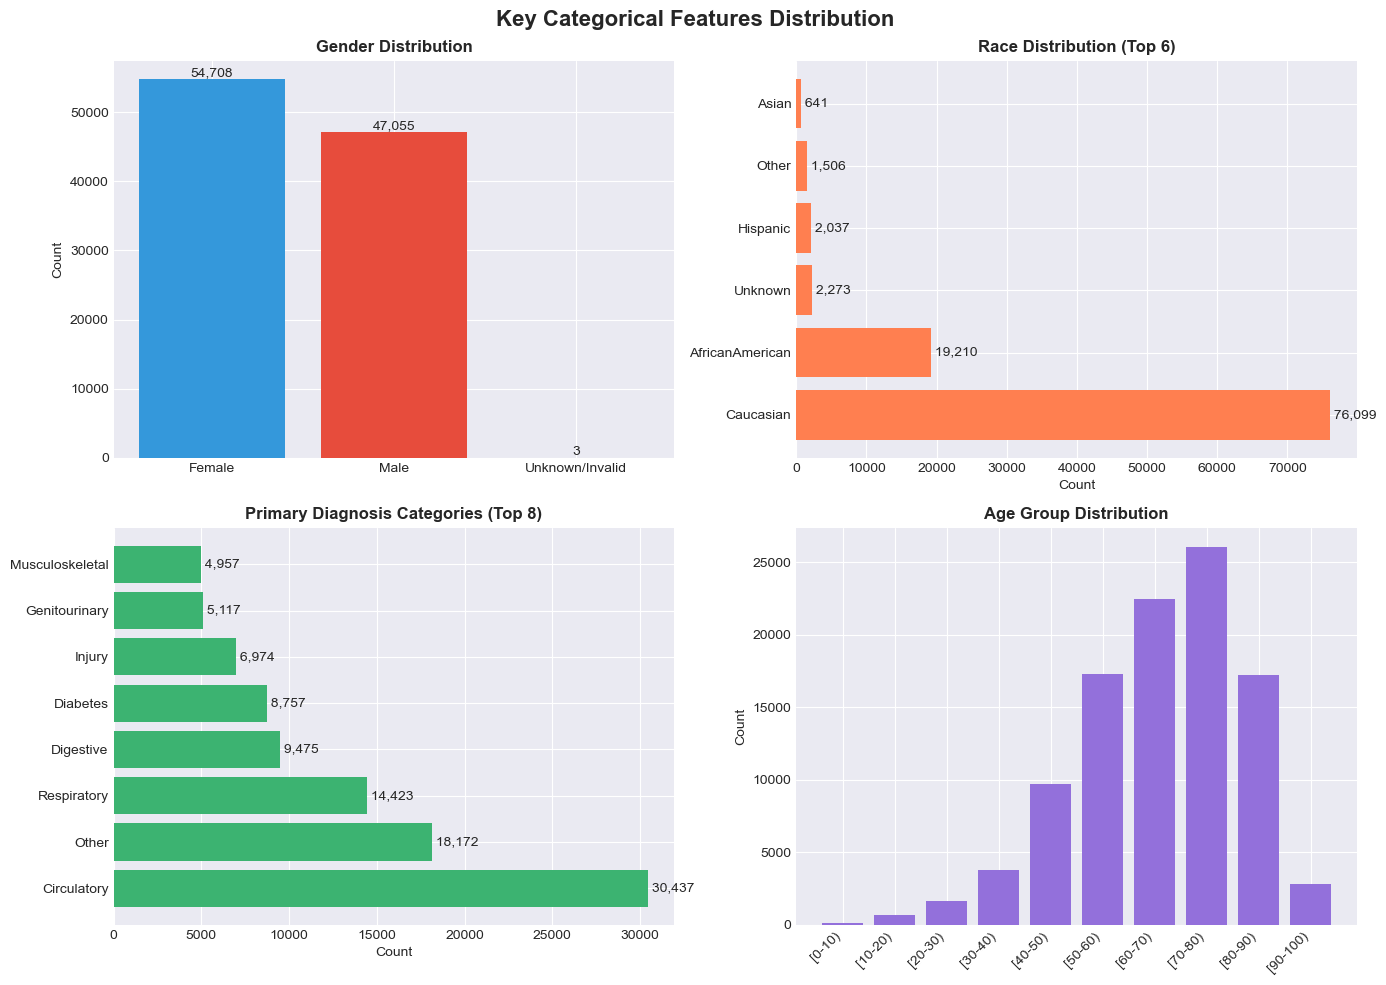

In [36]:
# ============================================================================
# SECTION 6: EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================================

"""
EDA helps us understand:
1. Individual feature distributions
2. Relationships between features
3. Patient readmission patterns
4. Healthcare insights and trends

We'll create visualizations to better understand the dataset.
"""

print("\n\n" + "=" * 80)
print("EXPLORATORY DATA ANALYSIS")
print("=" * 80)

# Create output directory for visualizations
import os
if not os.path.exists('visualizations'):
    os.makedirs('visualizations')
    print("✓ Created 'visualizations' directory for output")

# 6.1 UNIVARIATE ANALYSIS - NUMERIC FEATURES
print("\n1. UNIVARIATE ANALYSIS - NUMERIC FEATURES")
print("-" * 80)

# Select key numeric features for analysis
numeric_features = ['time_in_hospital', 'num_lab_procedures', 'num_procedures',
                   'num_medications', 'number_outpatient', 'number_emergency',
                   'number_inpatient', 'number_diagnoses', 'age_numeric']

# Create distribution plots
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle('Distribution of Numeric Features', fontsize=16, fontweight='bold', y=1.00)

for idx, col in enumerate(numeric_features):
    if col in df.columns:
        row = idx // 3
        col_idx = idx % 3
        ax = axes[row, col_idx]

        # Histogram with KDE
        df[col].hist(bins=30, ax=ax, alpha=0.7, color='steelblue', edgecolor='black')
        ax.set_title(f'{col}\n(Mean: {df[col].mean():.2f}, Median: {df[col].median():.2f})',
                    fontsize=11)
        ax.set_xlabel('Value')
        ax.set_ylabel('Frequency')
        ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('visualizations/02_numeric_distributions.png', dpi=300, bbox_inches='tight')
print("✓ Saved: visualizations/02_numeric_distributions.png")
plt.show()

# Statistical summary
print("\nStatistical Summary of Numeric Features:")
print(df[numeric_features].describe().round(2))

# 6.2 UNIVARIATE ANALYSIS - CATEGORICAL FEATURES
print("\n\n2. UNIVARIATE ANALYSIS - CATEGORICAL FEATURES")
print("-" * 80)

# Gender distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Key Categorical Features Distribution', fontsize=16, fontweight='bold')

# Gender
if 'gender' in df.columns:
    gender_counts = df['gender'].value_counts()
    axes[0, 0].bar(gender_counts.index, gender_counts.values, color=['#3498db', '#e74c3c', '#95a5a6'])
    axes[0, 0].set_title('Gender Distribution', fontweight='bold')
    axes[0, 0].set_ylabel('Count')
    for i, v in enumerate(gender_counts.values):
        axes[0, 0].text(i, v, f'{v:,}', ha='center', va='bottom')

# Race
if 'race' in df.columns:
    race_counts = df['race'].value_counts().head(6)
    axes[0, 1].barh(race_counts.index, race_counts.values, color='coral')
    axes[0, 1].set_title('Race Distribution (Top 6)', fontweight='bold')
    axes[0, 1].set_xlabel('Count')
    for i, v in enumerate(race_counts.values):
        axes[0, 1].text(v, i, f' {v:,}', va='center')

# Primary Diagnosis Category
if 'diag_1_category' in df.columns:
    diag_counts = df['diag_1_category'].value_counts().head(8)
    axes[1, 0].barh(diag_counts.index, diag_counts.values, color='mediumseagreen')
    axes[1, 0].set_title('Primary Diagnosis Categories (Top 8)', fontweight='bold')
    axes[1, 0].set_xlabel('Count')
    for i, v in enumerate(diag_counts.values):
        axes[1, 0].text(v, i, f' {v:,}', va='center')

# Age Distribution
if 'age' in df.columns:
    age_counts = df['age'].value_counts().sort_index()
    axes[1, 1].bar(range(len(age_counts)), age_counts.values, color='mediumpurple')
    axes[1, 1].set_title('Age Group Distribution', fontweight='bold')
    axes[1, 1].set_xticks(range(len(age_counts)))
    axes[1, 1].set_xticklabels(age_counts.index, rotation=45, ha='right')
    axes[1, 1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('visualizations/03_categorical_distributions.png', dpi=300, bbox_inches='tight')
print("✓ Saved: visualizations/03_categorical_distributions.png")
plt.show()



3. BIVARIATE ANALYSIS - READMISSION PATTERNS
--------------------------------------------------------------------------------

Analyzing numeric features across readmission categories...
✓ Saved: visualizations/04_numeric_vs_readmission.png


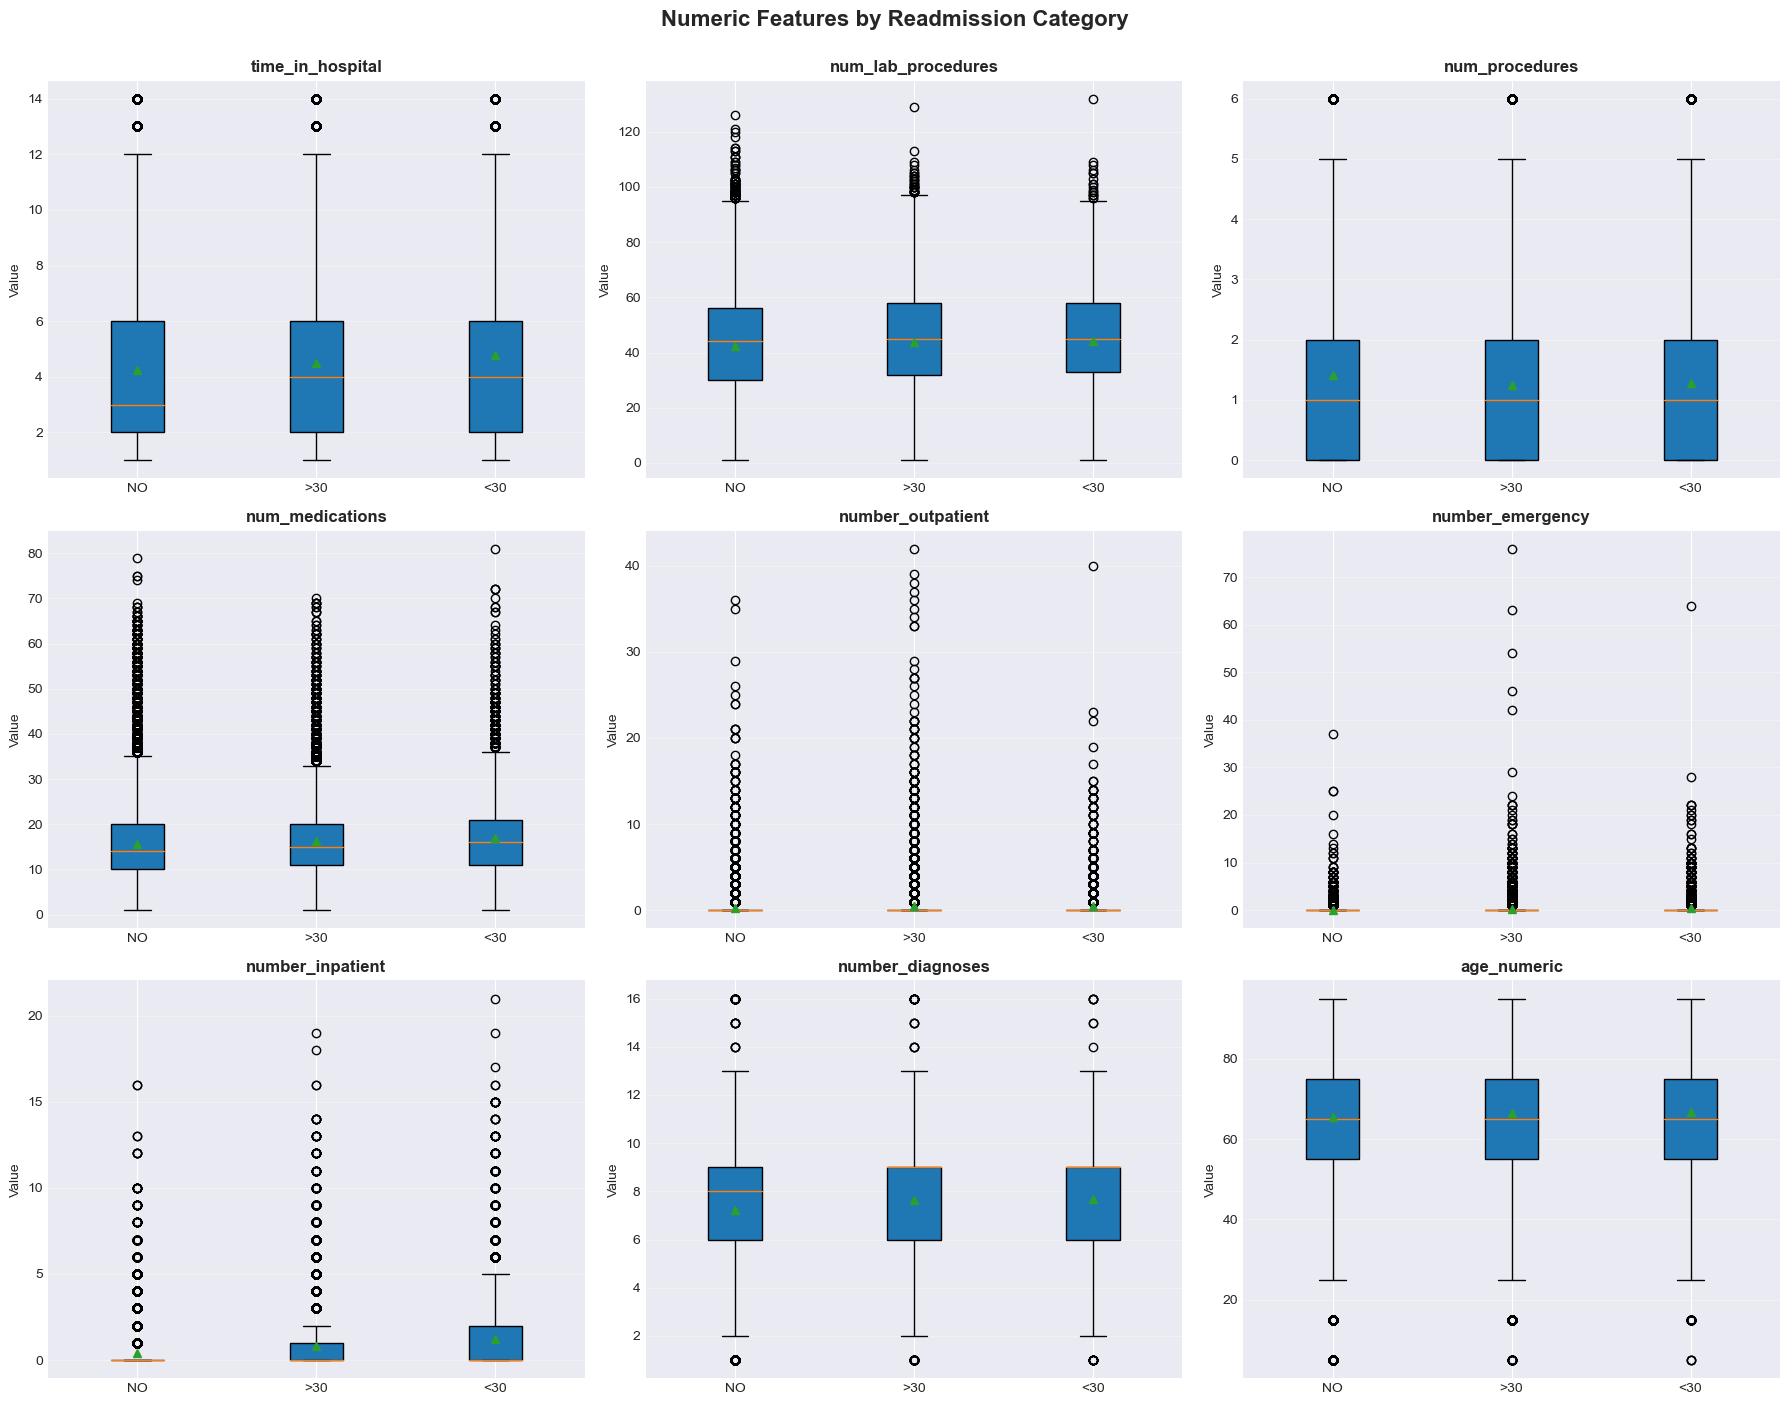


AVERAGE VALUES BY READMISSION CATEGORY
--------------------------------------------------------------------------------

time_in_hospital
readmitted
<30    4.77
>30    4.50
NO     4.25
Name: time_in_hospital, dtype: float64

num_lab_procedures
readmitted
<30    44.23
>30    43.84
NO     42.38
Name: num_lab_procedures, dtype: float64

num_procedures
readmitted
<30    1.28
>30    1.25
NO     1.41
Name: num_procedures, dtype: float64

num_medications
readmitted
<30    16.90
>30    16.28
NO     15.67
Name: num_medications, dtype: float64

number_outpatient
readmitted
<30    0.44
>30    0.50
NO     0.27
Name: number_outpatient, dtype: float64

number_emergency
readmitted
<30    0.36
>30    0.28
NO     0.11
Name: number_emergency, dtype: float64

number_inpatient
readmitted
<30    1.22
>30    0.84
NO     0.38
Name: number_inpatient, dtype: float64

number_diagnoses
readmitted
<30    7.69
>30    7.65
NO     7.22
Name: number_diagnoses, dtype: float64

age_numeric
readmitted
<30    66.76
>30 

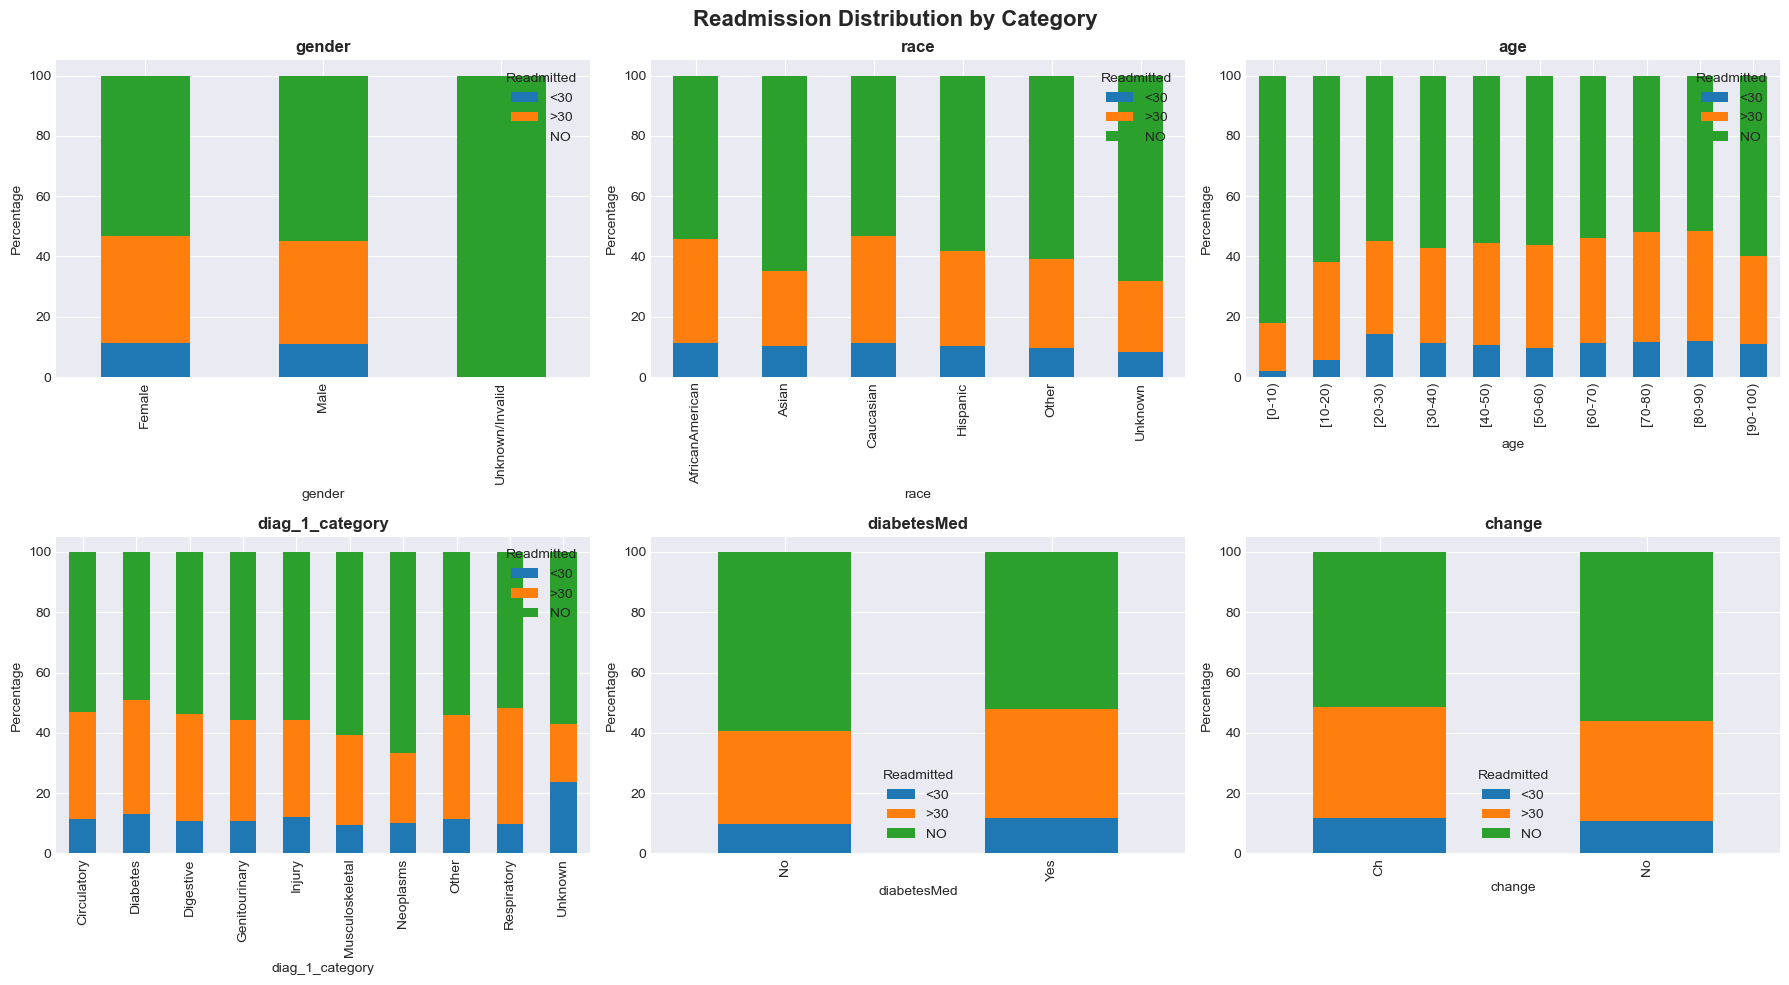



3.3 CORRELATION ANALYSIS
--------------------------------------------------------------------------------
✓ Saved: visualizations/06_correlation_matrix.png


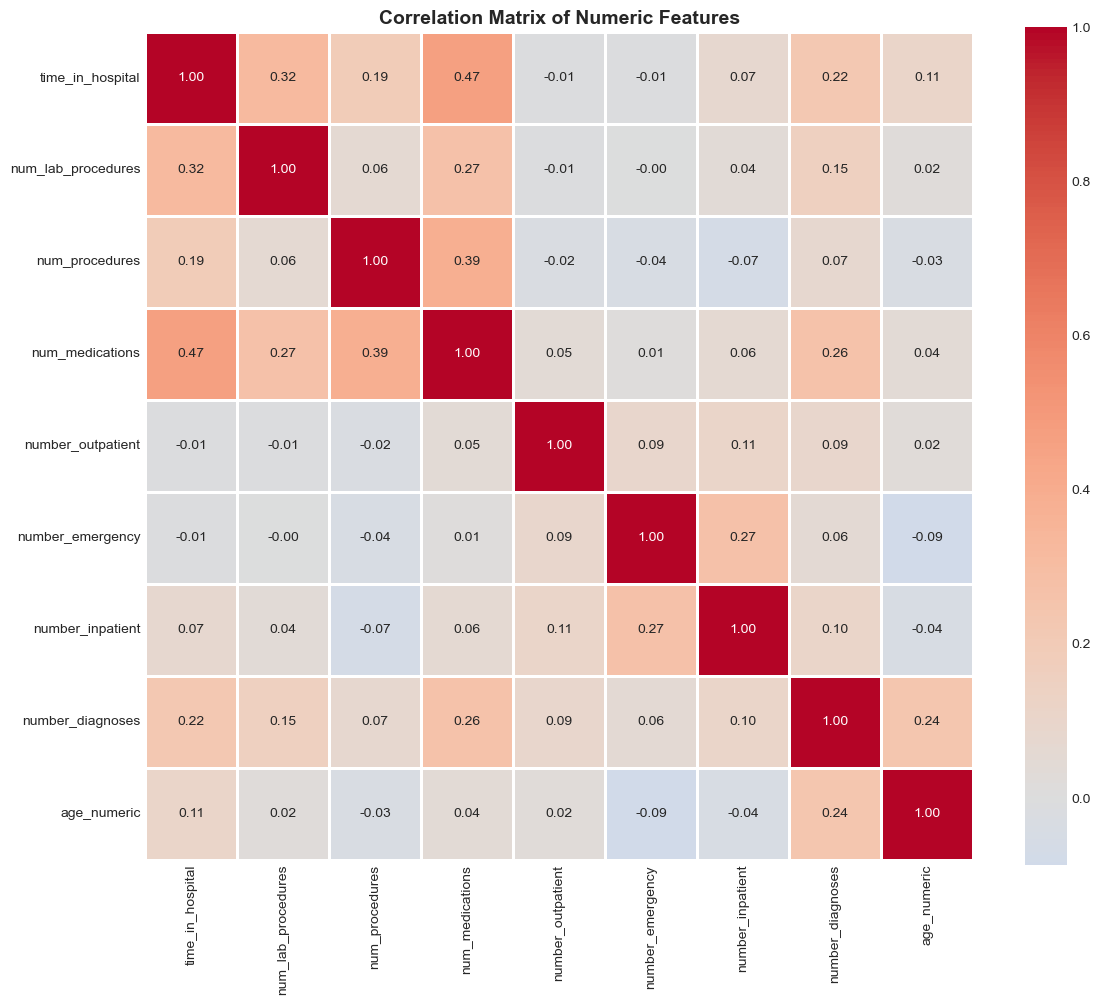


Strongest Correlations:
--------------------------------------------------------------------------------
time_in_hospital    time_in_hospital      1.000000
num_medications     time_in_hospital      0.466135
num_procedures      num_medications       0.385767
num_lab_procedures  time_in_hospital      0.318450
                    num_medications       0.268161
number_inpatient    number_emergency      0.266559
number_diagnoses    num_medications       0.261526
                    age_numeric           0.242597
time_in_hospital    number_diagnoses      0.220186
                    num_procedures        0.191472
number_diagnoses    num_lab_procedures    0.152773
age_numeric         time_in_hospital      0.107515
number_outpatient   number_inpatient      0.107338
number_inpatient    number_diagnoses      0.104710
number_diagnoses    number_outpatient     0.094152
dtype: float64


In [37]:
# ============================================================================
# 6.3 BIVARIATE ANALYSIS - READMISSION PATTERNS
# ============================================================================

print("\n\n3. BIVARIATE ANALYSIS - READMISSION PATTERNS")
print("-" * 80)

# 6.3.1 Numeric Features by Readmission Category
print("\nAnalyzing numeric features across readmission categories...")

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle(
    'Numeric Features by Readmission Category',
    fontsize=16,
    fontweight='bold',
    y=1.00
)

for idx, feature in enumerate(numeric_features):

    if feature in df.columns:

        row = idx // 3
        col = idx % 3
        ax = axes[row, col]

        data_to_plot = [
            df[df['readmitted'] == 'NO'][feature].dropna(),
            df[df['readmitted'] == '>30'][feature].dropna(),
            df[df['readmitted'] == '<30'][feature].dropna()
        ]

        ax.boxplot(
            data_to_plot,
            labels=['NO', '>30', '<30'],
            patch_artist=True,
            showmeans=True
        )

        ax.set_title(feature, fontweight='bold')
        ax.set_ylabel('Value')
        ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(
    'visualizations/04_numeric_vs_readmission.png',
    dpi=300,
    bbox_inches='tight'
)

print("✓ Saved: visualizations/04_numeric_vs_readmission.png")
plt.show()

# Average Values by Readmission Category

print("\nAVERAGE VALUES BY READMISSION CATEGORY")
print("-" * 80)

for feature in numeric_features:

    if feature in df.columns:

        print(f"\n{feature}")

        print(
            df.groupby('readmitted')[feature]
            .mean()
            .round(2)
        )

# 6.3.2 Categorical Features vs Readmission
print("\n\n3.2 CATEGORICAL FEATURES VS READMISSION")
print("-" * 80)

categorical_features = [
    'gender',
    'race',
    'age',
    'diag_1_category',
    'diabetesMed',
    'change'
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(
    'Readmission Distribution by Category',
    fontsize=16,
    fontweight='bold'
)

for idx, feature in enumerate(categorical_features):

    if feature in df.columns:

        row = idx // 3
        col = idx % 3
        ax = axes[row, col]

        distribution = pd.crosstab(
            df[feature],
            df['readmitted'],
            normalize='index'
        ) * 100

        distribution = distribution.head(10)

        distribution.plot(
            kind='bar',
            stacked=True,
            ax=ax
        )

        ax.set_title(feature, fontweight='bold')
        ax.set_ylabel('Percentage')
        ax.legend(title='Readmitted')

plt.tight_layout()

plt.savefig(
    'visualizations/05_categorical_vs_readmission.png',
    dpi=300,
    bbox_inches='tight'
)

print("✓ Saved: visualizations/05_categorical_vs_readmission.png")
plt.show()

# 6.3.3 Correlation Analysis
print("\n\n3.3 CORRELATION ANALYSIS")
print("-" * 80)

corr_columns = [
    col for col in numeric_features
    if col in df.columns
]

correlation_matrix = df[corr_columns].corr()

plt.figure(figsize=(12, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=1
)

plt.title(
    'Correlation Matrix of Numeric Features',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()

plt.savefig(
    'visualizations/06_correlation_matrix.png',
    dpi=300,
    bbox_inches='tight'
)

print("✓ Saved: visualizations/06_correlation_matrix.png")
plt.show()

print("\nStrongest Correlations:")
print("-" * 80)

corr_pairs = (
    correlation_matrix
    .unstack()
    .sort_values(
        ascending=False,
        key=lambda x: abs(x)
    )
)

print(corr_pairs.drop_duplicates().head(15))

In [38]:
# ============================================================================
# SECTION 7: KEY INSIGHTS FROM EDA
# ============================================================================

print("\n\n" + "=" * 80)
print("KEY INSIGHTS FROM EXPLORATORY ANALYSIS")
print("=" * 80)

"""
Summary of important findings from the analysis.
These insights help understand patient demographics,
hospital utilization patterns, and readmission trends.
"""

print("\n1. PATIENT DEMOGRAPHICS")
print("-" * 80)

if 'gender' in df.columns:
    gender_dist = df['gender'].value_counts(normalize=True) * 100

    print("Gender Distribution:")

    for gender, pct in gender_dist.items():
        print(f"  - {gender}: {pct:.1f}%")

if 'age_numeric' in df.columns:

    print("\nAge Statistics:")
    print(f"  - Mean Age: {df['age_numeric'].mean():.1f} years")
    print(f"  - Median Age: {df['age_numeric'].median():.1f} years")
    print(
        f"  - Patients over 60: "
        f"{(df['age_numeric'] >= 60).sum() / len(df) * 100:.1f}%"
    )

print("\n2. READMISSION STATISTICS")
print("-" * 80)

total_patients = len(df)

readmission_counts = df['readmitted'].value_counts()
readmission_percentages = (
    df['readmitted'].value_counts(normalize=True) * 100
)

print("Readmission Distribution:")

for category in readmission_counts.index:
    print(
        f"  - {category}: "
        f"{readmission_counts[category]:,} "
        f"({readmission_percentages[category]:.2f}%)"
    )

if '<30' in readmission_counts.index:
    print(
        f"\nPatients Readmitted Within 30 Days: "
        f"{readmission_counts['<30']:,}"
    )

print(f"Total Records Analyzed: {total_patients:,}")



KEY INSIGHTS FROM EXPLORATORY ANALYSIS

1. PATIENT DEMOGRAPHICS
--------------------------------------------------------------------------------
Gender Distribution:
  - Female: 53.8%
  - Male: 46.2%
  - Unknown/Invalid: 0.0%

Age Statistics:
  - Mean Age: 66.0 years
  - Median Age: 65.0 years
  - Patients over 60: 67.4%

2. READMISSION STATISTICS
--------------------------------------------------------------------------------
Readmission Distribution:
  - NO: 54,864 (53.91%)
  - >30: 35,545 (34.93%)
  - <30: 11,357 (11.16%)

Patients Readmitted Within 30 Days: 11,357
Total Records Analyzed: 101,766


In [39]:
# ============================================================================
# SECTION 8: HEALTHCARE INSIGHTS
# ============================================================================

print("\n\n" + "=" * 80)
print("HEALTHCARE INSIGHTS")
print("=" * 80)

print("\n1. HOSPITAL STAY ANALYSIS")
print("-" * 80)

if 'time_in_hospital' in df.columns:
    print(f"Average Length of Stay: {df['time_in_hospital'].mean():.2f} days")
    print(f"Median Length of Stay: {df['time_in_hospital'].median():.2f} days")

print("\n2. MEDICATION ANALYSIS")
print("-" * 80)

if 'num_medications' in df.columns:
    print(f"Average Number of Medications: {df['num_medications'].mean():.2f}")
    print(f"Maximum Number of Medications: {df['num_medications'].max()}")

print("\n3. READMISSION OVERVIEW")
print("-" * 80)

readmission_summary = (
    df['readmitted']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(readmission_summary)

print("\n4. MOST COMMON DIAGNOSES")
print("-" * 80)

if 'diag_1_category' in df.columns:
    print(df['diag_1_category'].value_counts().head(10))

print("\n5. AGE GROUP ANALYSIS")
print("-" * 80)

if 'age' in df.columns:
    age_summary = df['age'].value_counts().sort_index()
    print(age_summary)

print("\n✓ Healthcare insights generated successfully.")



HEALTHCARE INSIGHTS

1. HOSPITAL STAY ANALYSIS
--------------------------------------------------------------------------------
Average Length of Stay: 4.40 days
Median Length of Stay: 4.00 days

2. MEDICATION ANALYSIS
--------------------------------------------------------------------------------
Average Number of Medications: 16.02
Maximum Number of Medications: 81

3. READMISSION OVERVIEW
--------------------------------------------------------------------------------
NO     53.91
>30    34.93
<30    11.16
Name: readmitted, dtype: float64

4. MOST COMMON DIAGNOSES
--------------------------------------------------------------------------------
Circulatory        30437
Other              18172
Respiratory        14423
Digestive           9475
Diabetes            8757
Injury              6974
Genitourinary       5117
Musculoskeletal     4957
Neoplasms           3433
Unknown               21
Name: diag_1_category, dtype: int64

5. AGE GROUP ANALYSIS
---------------------------------

In [40]:
# ============================================================================
# SECTION 9: EXECUTIVE SUMMARY AND RECOMMENDATIONS
# ============================================================================

print("\n\n" + "=" * 80)
print("EXECUTIVE SUMMARY AND RECOMMENDATIONS")
print("=" * 80)

summary_report = f"""
{'='*80}
HEALTHCARE READMISSION DATA ANALYSIS - EXECUTIVE SUMMARY
{'='*80}

PROJECT OVERVIEW
----------------
This project analyzed hospital admission records of diabetes patients
to understand demographic characteristics, hospital utilization,
diagnosis patterns, medication usage, and readmission trends.

Total Records Analyzed: {len(df):,}

KEY FINDINGS
------------

1. PATIENT PROFILE
   - Majority of patients belong to middle-aged and elderly age groups.
   - Patient admissions are distributed across different gender and race categories.

2. HOSPITAL STAY ANALYSIS
   - Length of hospital stay varies among patients.
   - Some patients require significantly longer hospitalization periods than others.

3. HEALTHCARE UTILIZATION
   - Previous inpatient, outpatient, and emergency visits differ across patients.
   - Frequent hospital visits indicate higher healthcare service utilization.

4. DIAGNOSIS INSIGHTS
   - Circulatory, respiratory, digestive, and diabetes-related conditions
     represent major diagnosis categories.
   - Certain diagnosis groups appear more frequently in hospital admissions.

5. MEDICATION PATTERNS
   - Medication usage varies considerably among patients.
   - Patients with higher medication counts often have more complex treatment needs.

6. READMISSION ANALYSIS
   - Readmission outcomes show noticeable variation across patient groups.
   - Differences can be observed when comparing age groups, diagnosis categories,
     and healthcare utilization patterns.

RECOMMENDATIONS
---------------

1. Improve discharge planning for patients with frequent hospital visits.

2. Strengthen follow-up care and monitoring after discharge.

3. Improve patient monitoring and follow-up care after hospital discharge.

4. Focus additional attention on elderly patients and those with
   chronic health conditions.

5. Regularly monitor admission and readmission trends using data reports
   and visual dashboards.

6. Use data-driven insights to support healthcare planning and
   resource allocation.

PROJECT OUTCOME
---------------
The analysis successfully identified important trends related to
patient demographics, hospital stays, diagnosis categories,
medication usage, and readmission behavior.

The findings provide valuable insights that can support hospital
management, healthcare planning, and quality improvement initiatives.

{'='*80}
END OF REPORT
{'='*80}
"""

print(summary_report)

with open("EXECUTIVE_SUMMARY.txt", "w", encoding="utf-8") as f:
    f.write(summary_report)

print("\n✓ Executive summary saved to 'EXECUTIVE_SUMMARY.txt'")



EXECUTIVE SUMMARY AND RECOMMENDATIONS

HEALTHCARE READMISSION DATA ANALYSIS - EXECUTIVE SUMMARY

PROJECT OVERVIEW
----------------
This project analyzed hospital admission records of diabetes patients
to understand demographic characteristics, hospital utilization,
diagnosis patterns, medication usage, and readmission trends.

Total Records Analyzed: 101,766

KEY FINDINGS
------------

1. PATIENT PROFILE
   - Majority of patients belong to middle-aged and elderly age groups.
   - Patient admissions are distributed across different gender and race categories.

2. HOSPITAL STAY ANALYSIS
   - Length of hospital stay varies among patients.
   - Some patients require significantly longer hospitalization periods than others.

3. HEALTHCARE UTILIZATION
   - Previous inpatient, outpatient, and emergency visits differ across patients.
   - Frequent hospital visits indicate higher healthcare service utilization.

4. DIAGNOSIS INSIGHTS
   - Circulatory, respiratory, digestive, and diabetes-rela



CREATING FINAL DASHBOARD
✓ Saved: visualizations/FINAL_DASHBOARD.png


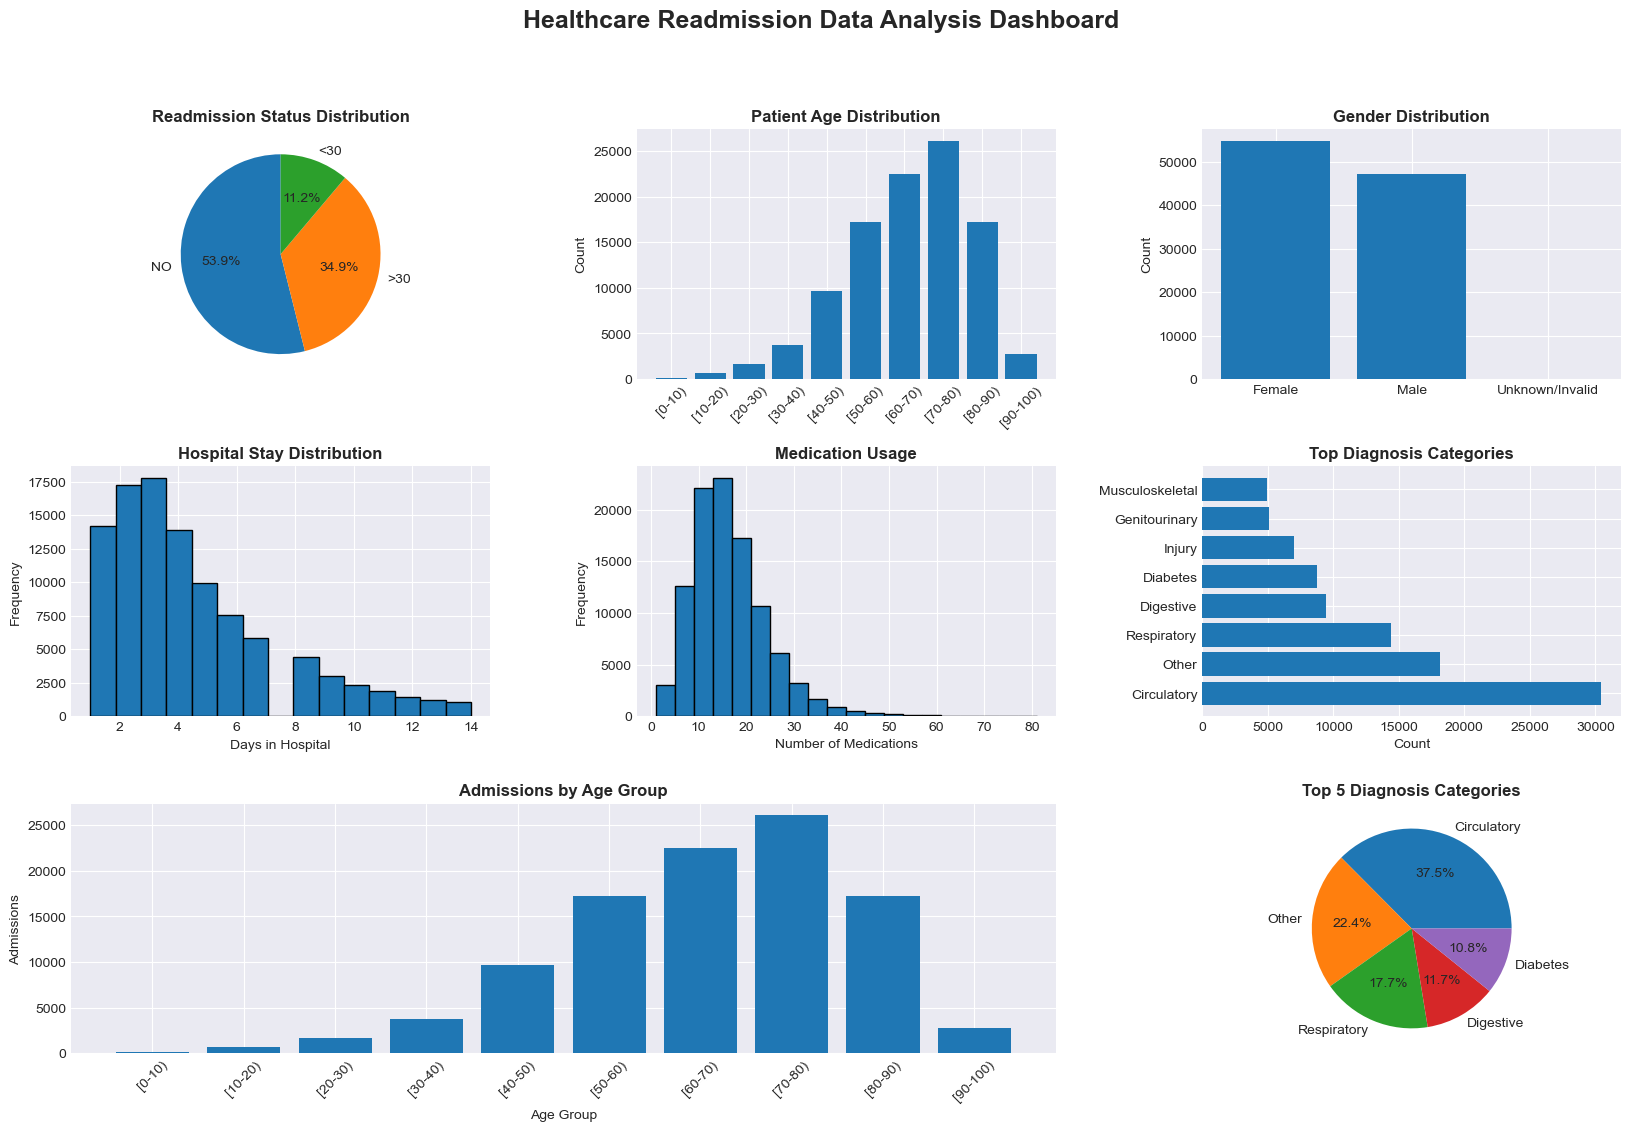


✓ Final dashboard created successfully!


In [41]:
# ============================================================================
# SECTION 11: FINAL DASHBOARD VISUALIZATION
# ============================================================================

print("\n\n" + "=" * 80)
print("CREATING FINAL DASHBOARD")
print("=" * 80)

fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.35)

# 1. Readmission Distribution
ax1 = fig.add_subplot(gs[0, 0])

readmit_counts = df['readmitted'].value_counts()

ax1.pie(
    readmit_counts.values,
    labels=readmit_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

ax1.set_title('Readmission Status Distribution', fontweight='bold')

# 2. Age Distribution
ax2 = fig.add_subplot(gs[0, 1])

age_order = sorted(df['age'].unique())
age_counts = df['age'].value_counts().reindex(age_order)

ax2.bar(range(len(age_counts)), age_counts.values)

ax2.set_xticks(range(len(age_counts)))
ax2.set_xticklabels(age_counts.index, rotation=45)

ax2.set_title('Patient Age Distribution', fontweight='bold')
ax2.set_ylabel('Count')

# 3. Gender Distribution
ax3 = fig.add_subplot(gs[0, 2])

gender_counts = df['gender'].value_counts()

ax3.bar(gender_counts.index, gender_counts.values)

ax3.set_title('Gender Distribution', fontweight='bold')
ax3.set_ylabel('Count')

# 4. Hospital Stay Distribution
ax4 = fig.add_subplot(gs[1, 0])

ax4.hist(
    df['time_in_hospital'],
    bins=15,
    edgecolor='black'
)

ax4.set_title('Hospital Stay Distribution', fontweight='bold')
ax4.set_xlabel('Days in Hospital')
ax4.set_ylabel('Frequency')

# 5. Medication Usage
ax5 = fig.add_subplot(gs[1, 1])

ax5.hist(
    df['num_medications'],
    bins=20,
    edgecolor='black'
)

ax5.set_title('Medication Usage', fontweight='bold')
ax5.set_xlabel('Number of Medications')
ax5.set_ylabel('Frequency')

# 6. Diagnosis Categories
ax6 = fig.add_subplot(gs[1, 2])

if 'diag_1_category' in df.columns:

    diag_counts = df['diag_1_category'].value_counts().head(8)

    ax6.barh(
        diag_counts.index,
        diag_counts.values
    )

    ax6.set_title('Top Diagnosis Categories', fontweight='bold')
    ax6.set_xlabel('Count')

# 7. Admissions by Age Group
ax7 = fig.add_subplot(gs[2, :2])

age_group_counts = (
    df.groupby('age')
      .size()
      .sort_index()
)

ax7.bar(
    age_group_counts.index,
    age_group_counts.values
)

ax7.set_title('Admissions by Age Group', fontweight='bold')
ax7.set_xlabel('Age Group')
ax7.set_ylabel('Admissions')

plt.setp(ax7.get_xticklabels(), rotation=45)

# 8. Top Diagnosis Categories Summary
ax8 = fig.add_subplot(gs[2, 2])

if 'diag_1_category' in df.columns:

    top_diag = (
        df['diag_1_category']
        .value_counts()
        .head(5)
    )

    ax8.pie(
        top_diag.values,
        labels=top_diag.index,
        autopct='%1.1f%%'
    )

    ax8.set_title('Top 5 Diagnosis Categories', fontweight='bold')

fig.suptitle(
    'Healthcare Readmission Data Analysis Dashboard',
    fontsize=18,
    fontweight='bold'
)

plt.savefig(
    'visualizations/FINAL_DASHBOARD.png',
    dpi=300,
    bbox_inches='tight'
)

print("✓ Saved: visualizations/FINAL_DASHBOARD.png")

plt.show()

print("\n✓ Final dashboard created successfully!")

In [48]:
print("\n\n" + "=" * 80)
print("PROJECT COMPLETION SUMMARY")
print("=" * 80)

print("\nDATASET OVERVIEW")
print(f"Total Records Analyzed: {len(df):,}")
print(f"Total Features: {df.shape[1]}")
print("Dataset Successfully Cleaned and Prepared for Analysis")

print("\nPATIENT ANALYSIS SUMMARY")

# Age
if 'age_numeric' in df.columns:
    print(f"Average Patient Age: {df['age_numeric'].mean():.2f} years")

# Hospital stay
if 'time_in_hospital' in df.columns:
    print(f"Average Hospital Stay: {df['time_in_hospital'].mean():.2f} days")

# Medications
if 'num_medications' in df.columns:
    print(f"Average Number of Medications: {df['num_medications'].mean():.2f}")


df['readmitted'] = df['readmitted'].astype(str).str.strip().str.lower()

readmission_rate = (df['readmitted'] == '<30').mean() * 100

print(f"30-Day Readmission Rate: {readmission_rate:.2f}%")

print("\nKEY FINDINGS")
print("• Patient demographics and age distribution were analyzed.")
print("• Hospital utilization patterns were examined.")
print("• Diagnosis category distributions were identified.")
print("• Medication usage trends were explored.")
print("• Readmission patterns were evaluated across patient groups.")

print("\nPROJECT OUTPUTS")
print("✓ Cleaned Dataset")
print("✓ Exploratory Data Analysis")
print("✓ Statistical Summaries")
print("✓ Data Visualizations")
print("✓ Executive Summary Report")

print("\nCONCLUSION")
print("The analysis provided valuable insights into patient demographics,")
print("hospital utilization, diagnosis patterns, medication usage, and")
print("readmission behavior. These findings can support better healthcare")
print("planning, resource allocation, and patient care management.")

print("\n" + "=" * 80)
print("PROJECT COMPLETED SUCCESSFULLY")
print("=" * 80)



PROJECT COMPLETION SUMMARY

DATASET OVERVIEW
Total Records Analyzed: 101,766
Total Features: 49
Dataset Successfully Cleaned and Prepared for Analysis

PATIENT ANALYSIS SUMMARY
Average Patient Age: 65.97 years
Average Hospital Stay: 4.40 days
Average Number of Medications: 16.02
30-Day Readmission Rate: 11.16%

KEY FINDINGS
• Patient demographics and age distribution were analyzed.
• Hospital utilization patterns were examined.
• Diagnosis category distributions were identified.
• Medication usage trends were explored.
• Readmission patterns were evaluated across patient groups.

PROJECT OUTPUTS
✓ Cleaned Dataset
✓ Exploratory Data Analysis
✓ Statistical Summaries
✓ Data Visualizations
✓ Executive Summary Report

CONCLUSION
The analysis provided valuable insights into patient demographics,
hospital utilization, diagnosis patterns, medication usage, and
readmission behavior. These findings can support better healthcare
planning, resource allocation, and patient care management.

PROJE